### Exploratory Data Analysis — Uncovering India's Weather Patterns

In [1]:
import pandas as pd
import numpy  as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df=pd.read_csv("C:/Internships/projects/WeatherLens India/clean_weather.csv")
df.head()

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,rain_sum,wind_speed_10m_max,rain_tomorrow,weather_condition,year,month,day,season,temp_range
0,Delhi,01-01-2000,19.9,7.4,19.2,5.8,0.0,10.9,0,Clear,2000,1,1,Winter,12.5
1,Delhi,02-01-2000,20.0,5.5,18.9,3.4,0.0,9.5,0,Overcast,2000,1,2,Winter,14.5
2,Delhi,03-01-2000,20.1,6.3,18.2,4.3,0.0,10.0,0,Clear,2000,1,3,Winter,13.8
3,Delhi,04-01-2000,19.8,6.4,18.5,4.2,0.0,8.6,0,Clear,2000,1,4,Winter,13.4
4,Delhi,05-01-2000,19.4,5.3,17.7,3.2,0.0,9.4,0,Clear,2000,1,5,Winter,14.1


In [3]:
df.shape

(91320, 15)

In [4]:
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 5)

95th percentile rainfall: 28.3 mm


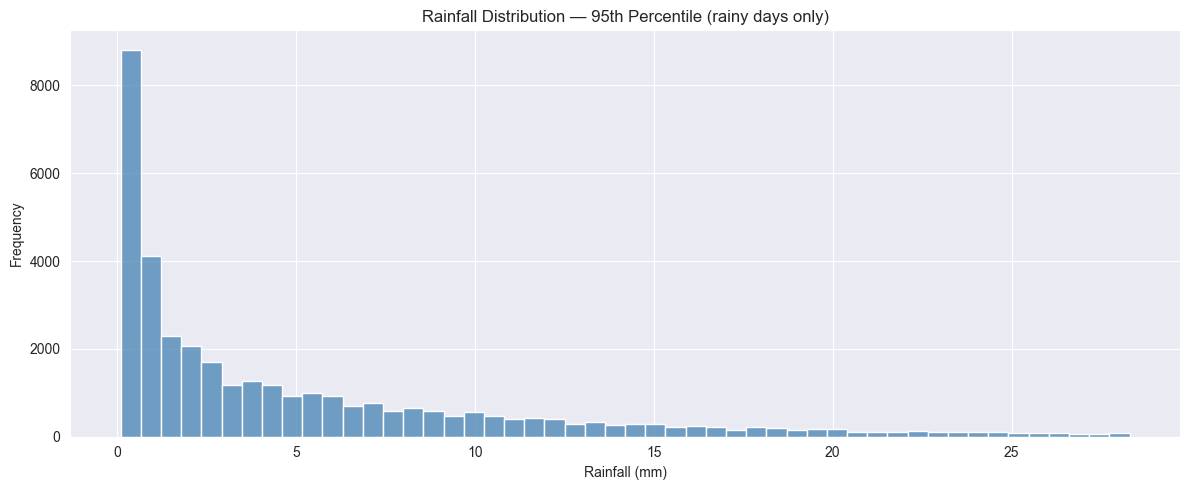

In [5]:
# 1. Rainfall distribution (rainy days only)
plt.figure()
rainy_days = df[df['rain_tomorrow'] == 1]['rain_sum']
upper_limit = rainy_days.quantile(0.95)
print("95th percentile rainfall:", upper_limit, "mm")
sns.histplot(rainy_days[rainy_days <= upper_limit], bins=50, color='steelblue')
plt.title('Rainfall Distribution — 95th Percentile (rainy days only)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

When filtered to the 95th percentile, most rainy days record between 0–2mm of rainfall, confirming that light rain dominates Indian weather patterns.<br>
 The distribution is strongly right skewed, meaning heavy rainfall events exist but are statistically rare across the dataset.

Q1: 0.7, Q3: 8.9, IQR: 8.200000000000001
Lower bound: -11.600000000000001, Upper bound: 21.200000000000003


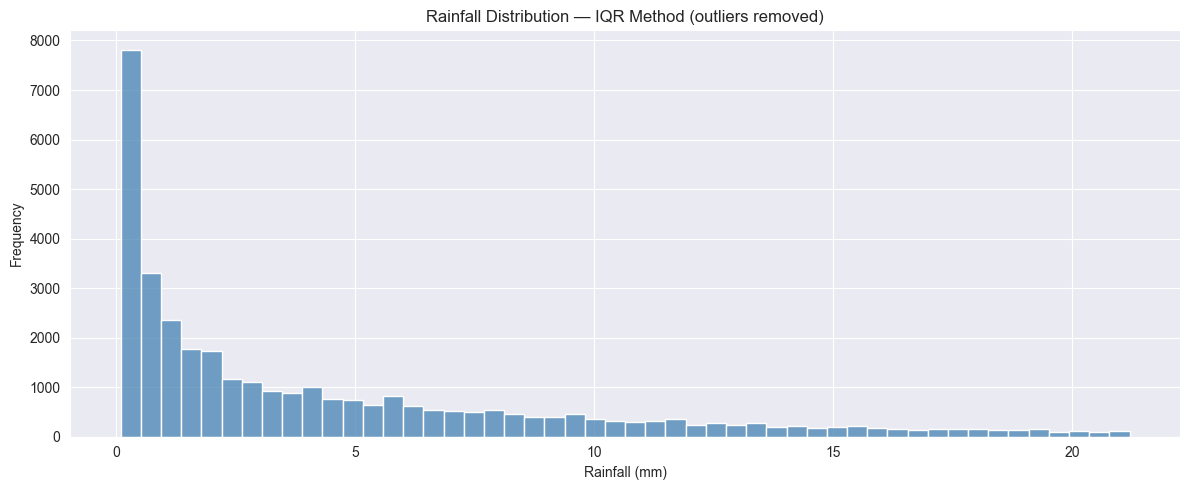

In [8]:
rainy_days = df[df['rain_tomorrow'] == 1]['rain_sum']

Q1 = rainy_days.quantile(0.25)
Q3 = rainy_days.quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Plot without outliers
clean_rain = rainy_days[(rainy_days >= lower_bound) & (rainy_days <= upper_bound)]

plt.figure()
sns.histplot(clean_rain, bins=50, color='steelblue')
plt.title('Rainfall Distribution — IQR Method (outliers removed)')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

The IQR method (Q1=0.7, Q3=8.9, Upper bound=21.2mm) provides a statistically grounded view of rainfall distribution.<br>
 The right skewed pattern is consistent majority of rainy days fall below 5mm. <br>
This confirms that extreme rainfall events are genuine outliers and not representative of typical Indian daily rainfall.


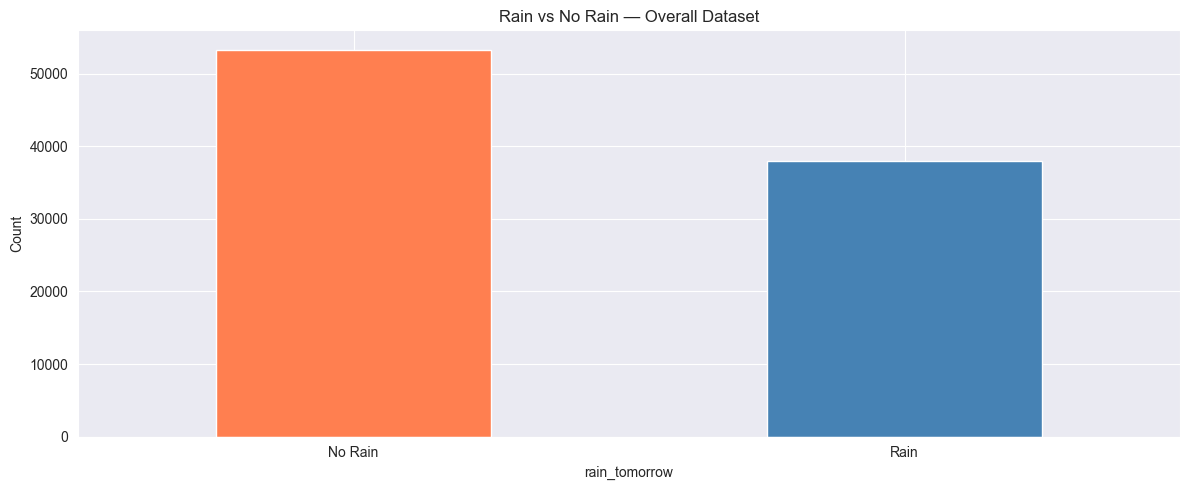

In [13]:
plt.figure()
df['rain_tomorrow'].value_counts().plot(kind='bar', color=['coral','steelblue'])
plt.title('Rain vs No Rain — Overall Dataset')
plt.xticks([0, 1], ['No Rain', 'Rain'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Across 91,320 daily records, approximately 58% of days recorded no rainfall while 42% recorded rainfall. <br>
This moderate class imbalance means plain accuracy is a misleading metric for our ML model. <br>
ROC-AUC and F1 Score will be used instead, and SMOTE will be applied during model training to handle this imbalance.

C:\Users\Apurva Malankar\AppData\Local\Temp\ipykernel_6820\169848076.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_rain.index, y=monthly_rain.values, palette='Blues_d')


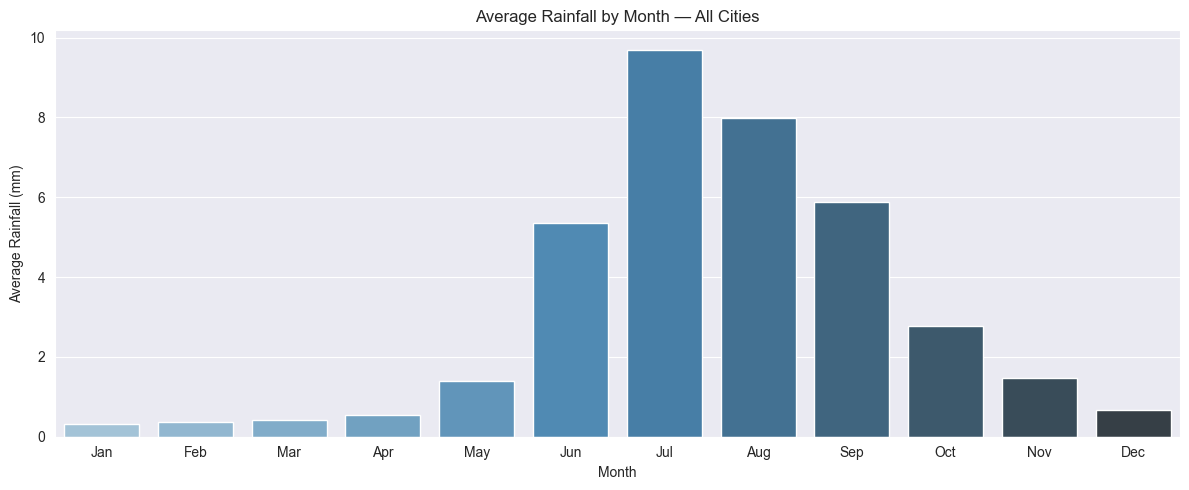

In [14]:
plt.figure(figsize=(12, 5))
monthly_rain = df.groupby('month')['rain_sum'].mean()
sns.barplot(x=monthly_rain.index, y=monthly_rain.values, palette='Blues_d')
plt.title('Average Rainfall by Month — All Cities')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

July records the highest average rainfall (~9.7mm) followed by August (~8mm), September (~6mm) and June (~5.4mm) — directly mapping to India's Southwest Monsoon season. <br>Winter months (January–March) record near zero rainfall.<br> This strong monthly seasonality confirms that month is one of the most powerful features for our ML model.

C:\Users\Apurva Malankar\AppData\Local\Temp\ipykernel_16564\2603976570.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_rain.index, y=city_rain.values, palette='Blues_d')


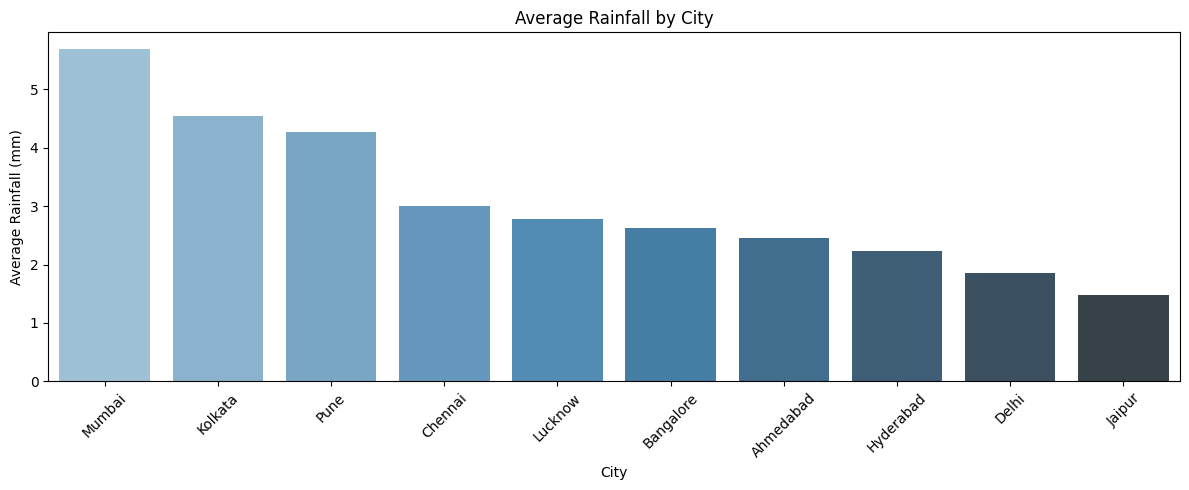

In [ ]:
plt.figure(figsize=(12, 5))
city_rain = df.groupby('city')['rain_sum'].mean().sort_values(ascending=False)
sns.barplot(x=city_rain.index, y=city_rain.values, palette='Blues_d')
plt.title('Average Rainfall by City')
plt.xlabel('City')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Mumbai tops the list at ~5.7mm average daily rainfall, driven by its west coast location and direct exposure to the Arabian Sea branch of the Southwest Monsoon, amplified by the Western Ghats acting as a barrier.<br> Kolkata ranks second due to the Bay of Bengal branch hitting eastern India strongly.<br> South Indian cities like Chennai and Bangalore rank lower despite expectations — Chennai receives its primary rainfall from the Northeast Monsoon in October–November rather than the dominant Southwest Monsoon.<br> Jaipur records the lowest rainfall, consistent with its semi-arid Rajasthan climate.

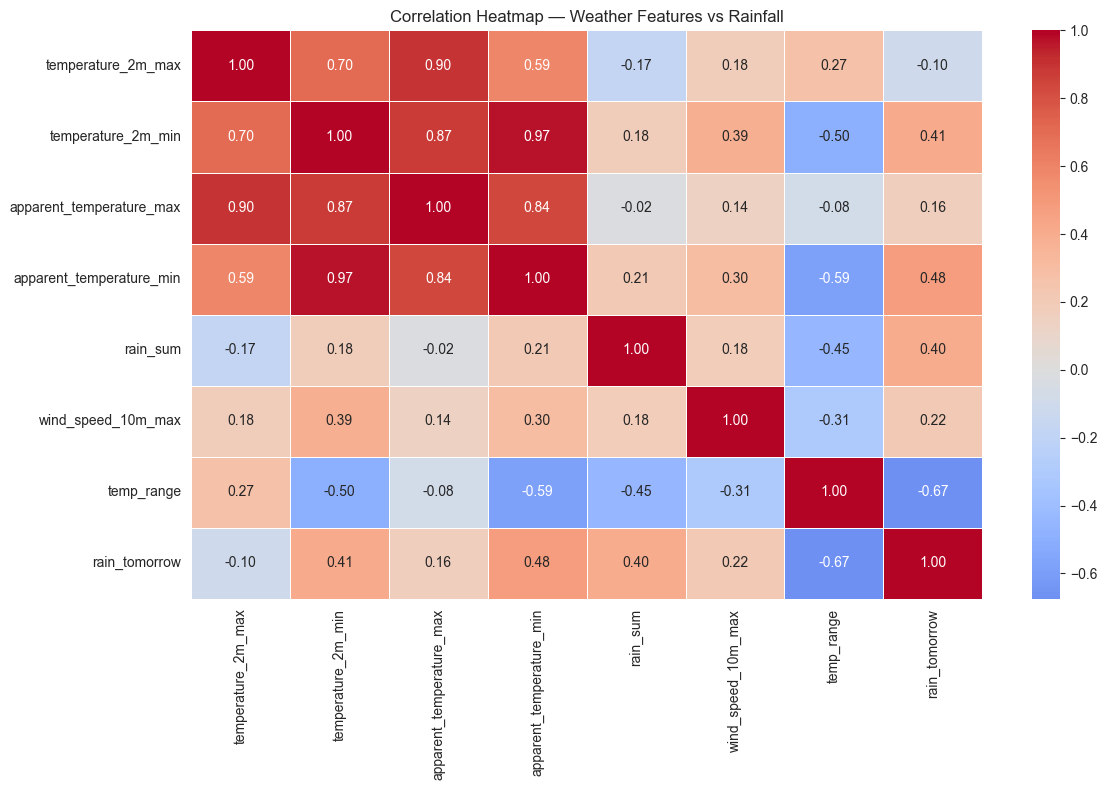

In [8]:
plt.figure(figsize=(12, 8))

# Select only numerical columns
numerical_cols = ['temperature_2m_max', 'temperature_2m_min',
                  'apparent_temperature_max', 'apparent_temperature_min',
                  'rain_sum', 'wind_speed_10m_max', 
                   'temp_range', 'rain_tomorrow']

correlation = df[numerical_cols].corr()

sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Correlation Heatmap — Weather Features vs Rainfall')
plt.tight_layout()
plt.show()

The heatmap reveals that temp_range has the strongest correlation with rain_tomorrow at -0.67 — meaning smaller temperature gaps between day and night strongly predict rainfall.<br> apparent_temperature_min follows at 0.48, and rain_sum at 0.40. Notably, wind_direction shows near zero correlation (-0.01) making it useless for prediction — justifying its removal from the dataset.<br> wind_speed and wind_gusts show 0.91 correlation with each other, meaning they carry duplicate information — one was dropped to avoid multicollinearity.

In [ ]:
df.drop(columns=['wind_direction_10m_dominant', 
                 'wind_gusts_10m_max'], inplace=True)

In [14]:
df.columns.tolist()

['city',
 'date',
 'temperature_2m_max',
 'temperature_2m_min',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'rain_sum',
 'wind_speed_10m_max',
 'rain_tomorrow',
 'weather_condition',
 'year',
 'month',
 'day',
 'season',
 'temp_range']

In [17]:
df.to_csv('clean_weather.csv', index=False)
print("clean_weather.csv updated!")

clean_weather.csv updated!


In [16]:
df.columns.tolist() 

['city',
 'date',
 'temperature_2m_max',
 'temperature_2m_min',
 'apparent_temperature_max',
 'apparent_temperature_min',
 'rain_sum',
 'wind_speed_10m_max',
 'rain_tomorrow',
 'weather_condition',
 'year',
 'month',
 'day',
 'season',
 'temp_range']

C:\Users\Apurva Malankar\AppData\Local\Temp\ipykernel_16564\4027636692.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_rain.index, y=season_rain.values, palette='Blues_d')


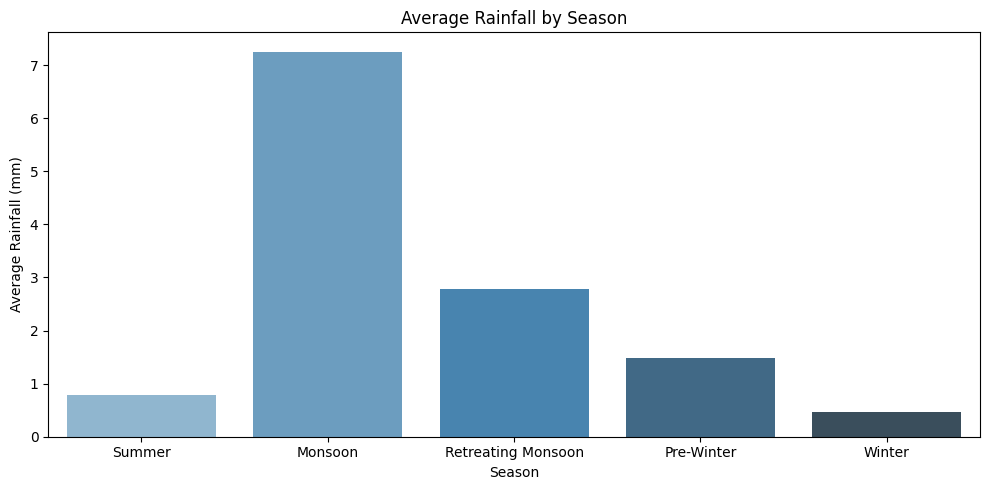

In [20]:
plt.figure(figsize=(10, 5))
season_order = ['Summer', 'Monsoon', 'Retreating Monsoon', 'Pre-Winter', 'Winter']
season_rain = df.groupby('season')['rain_sum'].mean().reindex(season_order)
sns.barplot(x=season_rain.index, y=season_rain.values, palette='Blues_d')
plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Average Rainfall (mm)')
plt.tight_layout()
plt.show()

Monsoon season dominates with ~7.2mm average daily rainfall — nearly 3x higher than any other season.<br> Retreating Monsoon (October) still contributes significantly at ~2.8mm, validating our decision to treat it as a separate season rather than grouping it with Post-Monsoon.<br> This chart directly proves that our custom season engineering captured Indian climate reality more accurately than a standard four-season approach.

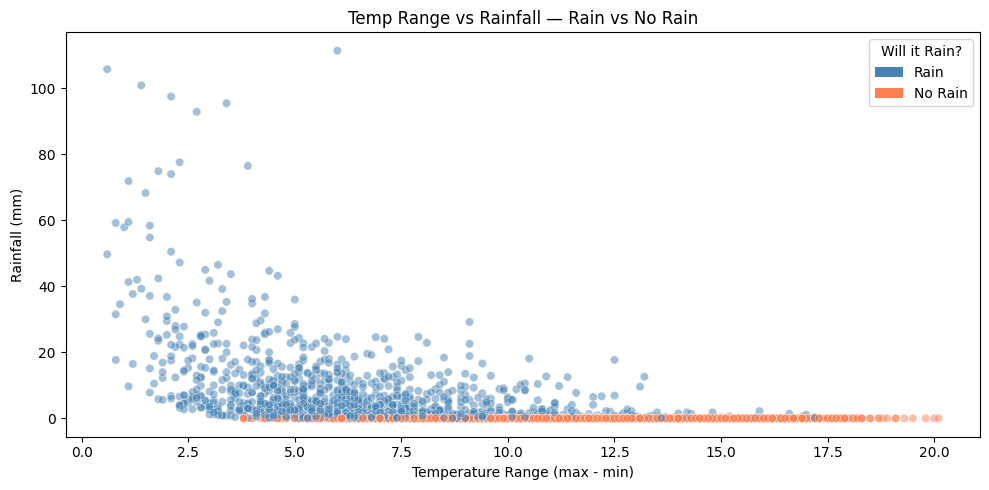

In [ ]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df.sample(3000), 
                x='temp_range', 
                y='rain_sum', 
                hue='rain_tomorrow',
                palette={0:'coral', 1:'steelblue'},
                alpha=0.5)
plt.title('Temp Range vs Rainfall — Rain vs No Rain')
plt.xlabel('Temperature Range (max - min)')
plt.ylabel('Rainfall (mm)')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Rain'),
                   Patch(facecolor='coral', label='No Rain')]
plt.legend(handles=legend_elements, title='Will it Rain?')

plt.tight_layout()
plt.show()

This chart visually proves the -0.67 correlation found in the heatmap. Blue dots (rainy days) cluster heavily on the left side (temp range 0–5°C) with high rainfall values, while orange dots (no rain days) spread across the right side (temp range 10–20°C) sitting flat at 0mm.<br> Days with small temperature gaps are cloudy — cloud cover blocks sunlight keeping temperatures stable, and those same clouds produce rain. This makes temp_range our single most powerful engineered feature. 

### SUMMARY

Analysis of 91,320 daily weather records across 10 Indian cities (2000–2024) revealed three key findings:<br> Rainfall is strongly seasonal peaking in July, strongly geographic with Mumbai leading all cities, and most accurately predicted by temperature range — an engineered feature rather than any raw measurement.